In [ ]:
!pip install -q ctgan ydata-profiling sdv DataSynthesizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.3/193.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.4/198.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            precision_score, recall_score, f1_score, roc_auc_score)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from ctgan import CTGAN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# from imblearn.over_sampling import ADASYN
# from imblearn.under_sampling import NearMiss, EditedNearestNeighbours, TomekLinks
# from imblearn.combine import SMOTEENN, SMOTETomek

from DataSynthesizer.DataDescriber import DataDescriber
from DataSynthesizer.DataGenerator import DataGenerator

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer


import warnings
warnings.filterwarnings('ignore')

In [ ]:
# import data from csv

df = pd.read_csv('/content/selected_data.csv')


In [ ]:
df.isna().sum()

total_missing = df.isna().sum().sum()
print(f"Total number of missing values: {total_missing}")

# inf_count = df.apply(lambda x: np.isinf(x).sum())
# print("Infinite values per column:")
# print(inf_count)

total_inf = np.isinf(df).sum().sum()
print(f"Total number of infinite values: {total_inf}")


Total number of missing values: 0
Total number of infinite values: 0


In [1]:
profile = ProfileReport(df, title="Profiling Report", minimal=True)
profile

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

unique_counts = y.value_counts()
print(unique_counts)

label
0    784
1     82
Name: count, dtype: int64


In [ ]:
# train-test splot 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

In [ ]:
n_rows, n_cols = df.shape
print(f"Original Dataset Shape: {n_rows:,} rows × {n_cols} columns")

print(f'\nTrain Split : {len(y_train)} samples')
#unique from train set
unique_train_counts = y_train.value_counts()
print(unique_train_counts)

Original Dataset Shape: 866 rows × 200 columns

Train Split : 606 samples
label
0    549
1     57
Name: count, dtype: int64


In [ ]:
def get_metrics(y_test, y_pred, y_pred_proba):
  metrics = {
    'accuracy': (y_pred == y_test).mean(),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
  return metrics


In [ ]:
def run_experiment_collect_metrics(X_train, y_train, X_test, y_test):

  # scale for models
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # define models to iterate over
  models = {
    "Dummy": DummyClassifier(strategy='most_frequent', random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0)

  }

  # iterate over models
  report_results = {}
  metrics = {}
  for name, model in models.items():
      print(f'\nClassifier: {name}')
      clf = Pipeline(steps=[("classifier", model)]).fit(X_train_scaled, y_train)
      predictions = clf.predict(X_test_scaled)
      predictions_proba = clf.predict_proba(X_test_scaled)[:,1]

      #train_results = classification_report_df(y_test, predictions)
      #results[name] = train_results

      # # inside the loop after predictions computed
      # print("Pred distribution:", pd.Series(predictions).value_counts())
      # print("Unique in y_test:", pd.Series(y_test).value_counts())
      # print("Any positive preds?", (predictions == 1).sum())
      # print("Pred proba stats:", predictions_proba.min(), predictions_proba.mean(), predictions_proba.max())


      report_results[name] = classification_report(y_test, predictions, zero_division=0)

      model_metrics = get_metrics(y_test, predictions, predictions_proba)

      metrics[name] = model_metrics
      print(f"F1 Score: {model_metrics['f1']}")

  return report_results, metrics


In [ ]:
def NoAugmentation(X_train = X_train, y_train = y_train):
  print("\n==== No Sampling for Baseline ====")
  return X_train, y_train

def SMOTE_Oversampler(X_train = X_train, y_train = y_train):
  print("\n==== Sampling with SMOTE Oversampler ====")
  return SMOTE().fit_resample(X_train, y_train)

def Undersampler(X_train = X_train, y_train = y_train):
  print("\n==== Sampling with RandomUnderSampler ====")
  return RandomUnderSampler().fit_resample(X_train, y_train)


In [ ]:
def SDV_Sampler(X_train = X_train, y_train = y_train):
  print("\n==== Sampling with SDV Sampler ====")

  train_df = X_train.copy()
  train_df['label'] = y_train

  metadata = SingleTableMetadata()
  metadata.detect_from_dataframe(data=train_df)

  for col in train_df.columns:
    if col not in ['Catalog Number', 'label']: # and train_df[col].dtype in ['int64', 'float64']:
      metadata.update_column(col, sdtype='numerical')

  metadata.update_column('Catalog Number', sdtype='id')
  metadata.update_column('label', sdtype='categorical')
  #display(metadata.visualize())

  # separating minority subset
  minority_df = train_df[train_df['label'] == 1].copy()

  synthesizer = GaussianCopulaSynthesizer(metadata)
  synthesizer.fit(minority_df)

  # make classes equal
  n_to_generate = len(train_df[train_df['label'] == 0]) - len(minority_df)
  print(f"..Generating {n_to_generate} synthetic samples for minority class...")
  synthetic_minority = synthesizer.sample(num_rows=n_to_generate)

  balanced_df = pd.concat([ train_df, synthetic_minority ], ignore_index=True)
  balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

  X_train_aug = balanced_df.drop('label', axis=1)
  y_train_aug = balanced_df['label']

  print(f"\nSynthetic data generation complete!")
  print(f"   Synthetic samples added: {len(synthetic_minority):,}")
  print(f"   Augmented dataset size: {len(balanced_df):,}\n")

  # print number of samples per class in augmented dataset
  class_counts = y_train_aug.value_counts()
  for label, count in class_counts.items():
      print(f"   Number of samples in Class {label}: {count:,}")

  return X_train_aug, y_train_aug



In [ ]:

def Data_Synthesizer(X_train, y_train):
    print("\n==== Sampling with DataSynthesizer ====")
    """
    mode : str
        Synthesizer mode. Options:
          - 'independent'
          - 'correlated' (default)
          - 'bayesian_network'
    """

    categorical_cols = ['label']
    max_parents = 3  # for correlated mode
    mode = 'correlated'  # or 'independent' / 'bayesian_network'

    train_df = X_train.copy()
    train_df['label'] = y_train

    # minority class only
    minority_df = train_df[train_df['label'] == 1].copy()

    n_synthetic = max(0, len(train_df[train_df['label'] == 0]) - len(minority_df))
    if n_synthetic == 0:
        print("No imbalance detected. Skipping DataSynthesizer synthesis.")
        return X_train, y_train

    categorical_attributes = {col: True for col in categorical_cols}

    describer = DataDescriber()

    with tempfile.TemporaryDirectory() as tmpdir:
        input_file = os.path.join(tmpdir, "input.csv")
        description_file = os.path.join(tmpdir, "description.json")

        minority_df.to_csv(input_file, index=False)

        if mode == 'independent':
            describer.describe_dataset_in_independent_attribute_mode(
                dataset_file=input_file,
                attribute_to_is_categorical=categorical_attributes,
                attribute_to_is_candidate_key={}
            )
        elif mode == 'correlated':
            describer.describe_dataset_in_correlated_attribute_mode(
                dataset_file=input_file,
                attribute_to_is_categorical=categorical_attributes,
                epsilon=0,
                k=max_parents
            )
        elif mode == 'bayesian_network':
            describer.describe_dataset_in_bayesian_network_mode(
                dataset_file=input_file,
                attribute_to_is_categorical=categorical_attributes
            )
        else:
            raise ValueError(f"Invalid mode: {mode}")

        describer.save_dataset_description_to_file(description_file)

        generator = DataGenerator()
        print(f"..Generating {n_synthetic} synthetic samples for minority class.")

        if mode == 'independent':
            generator.generate_dataset_in_independent_mode(n_synthetic, description_file)
        elif mode == 'correlated':
            generator.generate_dataset_in_correlated_attribute_mode(n_synthetic, description_file)
        else:  # bayesian_network
            generator.generate_dataset_in_bayesian_network_mode(n_synthetic, description_file)

        synthetic_data = generator.synthetic_data

    # make sure label column is integer
    synthetic_data['label'] = synthetic_data['label'].astype(int)

    # combining original traindf and synthetic and shuffle
    augmented_df = pd.concat([train_df, synthetic_data], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Augmented dataset size: {len(augmented_df)}")

    X_train_aug = augmented_df.drop('label', axis=1)
    y_train_aug = augmented_df['label']

    return X_train_aug, y_train_aug


In [ ]:
# with multiple checks for robustness
def CTGAN_Sampler(X_train=X_train, y_train=y_train):
    print("\n==== Sampling with CTGAN ====")
    # Ensure DataFrames
    if not isinstance(X_train, pd.DataFrame):
        X_train = pd.DataFrame(X_train, columns=[f"f{i}" for i in range(X_train.shape[1])])
    if not isinstance(y_train, pd.DataFrame):
        y_train = pd.DataFrame(y_train, columns=['label'])


    train_df = pd.concat([X_train, y_train], axis=1)

    # --- Clean up label column first ---
    train_df['label'] = pd.to_numeric(train_df['label'], errors='coerce')  # turn anything non-numeric into NaN
    train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    train_df['label'].fillna(train_df['label'].mode()[0], inplace=True)   # fill NaN with most frequent class
    train_df['label'] = train_df['label'].astype(int)                     # now safe to convert

    # separate classes
    label_1 = train_df[train_df['label'] == 1].copy()
    label_0 = train_df[train_df['label'] == 0].copy()

    # clean minority class features
    label_1.replace([np.inf, -np.inf], np.nan, inplace=True)
    label_1.fillna(label_1.median(numeric_only=True), inplace=True)

    # number of synthetic samples needed
    n_synthetic = max(0, len(label_0) - len(label_1))
    print(f"..Generating {n_synthetic} synthetic samples for minority class...")

    if n_synthetic == 0:
        print("No imbalance detected. Skipping CTGAN synthesis.")
        return X_train, y_train

    # initialize and train CTGAN
    ctgan = CTGAN(
        epochs=100,
        batch_size=500,
        generator_dim=(128, 128),
        discriminator_dim=(128, 128),
        verbose=True
    )
    ctgan.fit(label_1, discrete_columns=['label'])
    #ctgan.fit(label_1, discrete_columns=discrete_cols)
    #ctgan.fit(label_1)

    # generating synthetic data
    synthetic_data = ctgan.sample(n_synthetic)

    # --- Clean synthetic output ---
    if 'label' not in synthetic_data.columns:
        synthetic_data['label'] = 1
    synthetic_data['label'] = pd.to_numeric(synthetic_data['label'], errors='coerce')
    synthetic_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    synthetic_data['label'].fillna(1, inplace=True)
    synthetic_data['label'] = synthetic_data['label'].astype(int)

    # merge train df and synthetic
    augmented_train = pd.concat([train_df, synthetic_data], ignore_index=True)
    augmented_train.dropna(subset=['label'], inplace=True)
    augmented_train = augmented_train.sample(frac=1, random_state=42).reset_index(drop=True)

    # split back for xtrain and ytrain
    X_train_aug = augmented_train.drop('label', axis=1)
    y_train_aug = augmented_train['label'].astype(int)

    print("\nSynthetic data generation complete!")
    print(f"   Synthetic samples added: {len(synthetic_data):,}")
    print(f"   Augmented dataset size: {len(augmented_train):,}")
    print(f"   Any NaNs in labels? {y_train_aug.isna().any()}")

    # # print number of samples per class in augmented dataset
    # class_counts = y_train_aug.value_counts()
    # for label, count in class_counts.items():
    #     print(f"   Number of samples in Class {label}: {count:,}")

    return X_train_aug, y_train_aug


In [ ]:

#samplers = [NoAugmentation, SMOTE_Oversampler, Undersampler, Data_Synthesizer, SDV_Sampler, CTGAN_Sampler, SDV_Plus, CTGAN_Plus]
# names = ['Baseline', 'SMOTE Oversample', 'Undersampling', 'DataSynthesizer', 'SDV Sampler', 'CT-GAN', 'SDV_Plus', 'CTGAN_Plus']

# samplers = [NoAugmentation, Undersampler, Data_Synthesizer, SDV_Sampler, CTGAN_Sampler]
# names = ['Baseline', 'Undersampling', 'DataSynthesizer', 'SDV Sampler', 'CT-GAN']


samplers = [NoAugmentation, Undersampler, SDV_Sampler, CTGAN_Sampler]
names = ['Baseline', 'Undersampling', 'SDV Sampler', 'CT-GAN']

samplers_metrics = {}

for i in range(len(samplers)):
  print("\n" + "="*50)
  print(f'\nUsing Sampling Method: {names[i]}. . .')
  print("="*50)

  X, y = samplers[i](X_train, y_train)

  # print name of data augmentation method and the size of augmented dataset
  # print number of samples per class in augmented dataset
  print(f'\n{names[i]} : {len(y)} samples')
  class_counts = y.value_counts()
  for label, count in class_counts.items():
    print(f"   Number of samples in Class {label}: {count:,}")

  results_for_sampler = run_experiment_collect_metrics(X, y, X_test, y_test)
  samplers_metrics[names[i]] = results_for_sampler

  print("\n" + "* - "*10)



Using Sampling Method: Baseline. . .

==== No Sampling for Baseline ====

Baseline : 606 samples
   Number of samples in Class 0: 549
   Number of samples in Class 1: 57

Classifier: Dummy
F1 Score: 0.0

Classifier: Random Forest
F1 Score: 0.07407407407407407

Classifier: XGBoost
F1 Score: 0.2

* - * - * - * - * - * - * - * - * - * - 


Using Sampling Method: Undersampling. . .

==== Sampling with RandomUnderSampler ====

Undersampling : 114 samples
   Number of samples in Class 0: 57
   Number of samples in Class 1: 57

Classifier: Dummy
F1 Score: 0.0

Classifier: Random Forest
F1 Score: 0.23809523809523808

Classifier: XGBoost
F1 Score: 0.25196850393700787

* - * - * - * - * - * - * - * - * - * - 


Using Sampling Method: SDV Sampler. . .

==== Sampling with SDV Sampler ====
..Generating 492 synthetic samples for minority class...

Synthetic data generation complete!
   Synthetic samples added: 492
   Augmented dataset size: 1,098

   Number of samples in Class 0: 549
   Number of 

Gen. (-2.17) | Discrim. (-1.01): 100%|██████████| 100/100 [00:42<00:00,  2.33it/s]



Synthetic data generation complete!
   Synthetic samples added: 492
   Augmented dataset size: 1,098
   Any NaNs in labels? False

CT-GAN : 1098 samples
   Number of samples in Class 0: 549
   Number of samples in Class 1: 549

Classifier: Dummy
F1 Score: 0.0

Classifier: Random Forest
F1 Score: 0.14285714285714285

Classifier: XGBoost
F1 Score: 0.1875

* - * - * - * - * - * - * - * - * - * - 


samplers_metrics structured as:

samplers_metrics = {

    "Baseline": (report_results_dict, metrics_dict),
    "Undersampling": (...),
    "SDV Sampler": (...),
    "CT-GAN": (...)
}

metrics_dict looks like:

metrics_dict = {

    "Dummy": {"accuracy": ..., "precision": ..., "recall": ..., "f1": ..., "roc_auc": ...},
    "Random Forest": {...},
    "XGBoost": {...}
}

F1 scores are at:

`samplers_metrics['Baseline'][1]['Random Forest']['f1']`


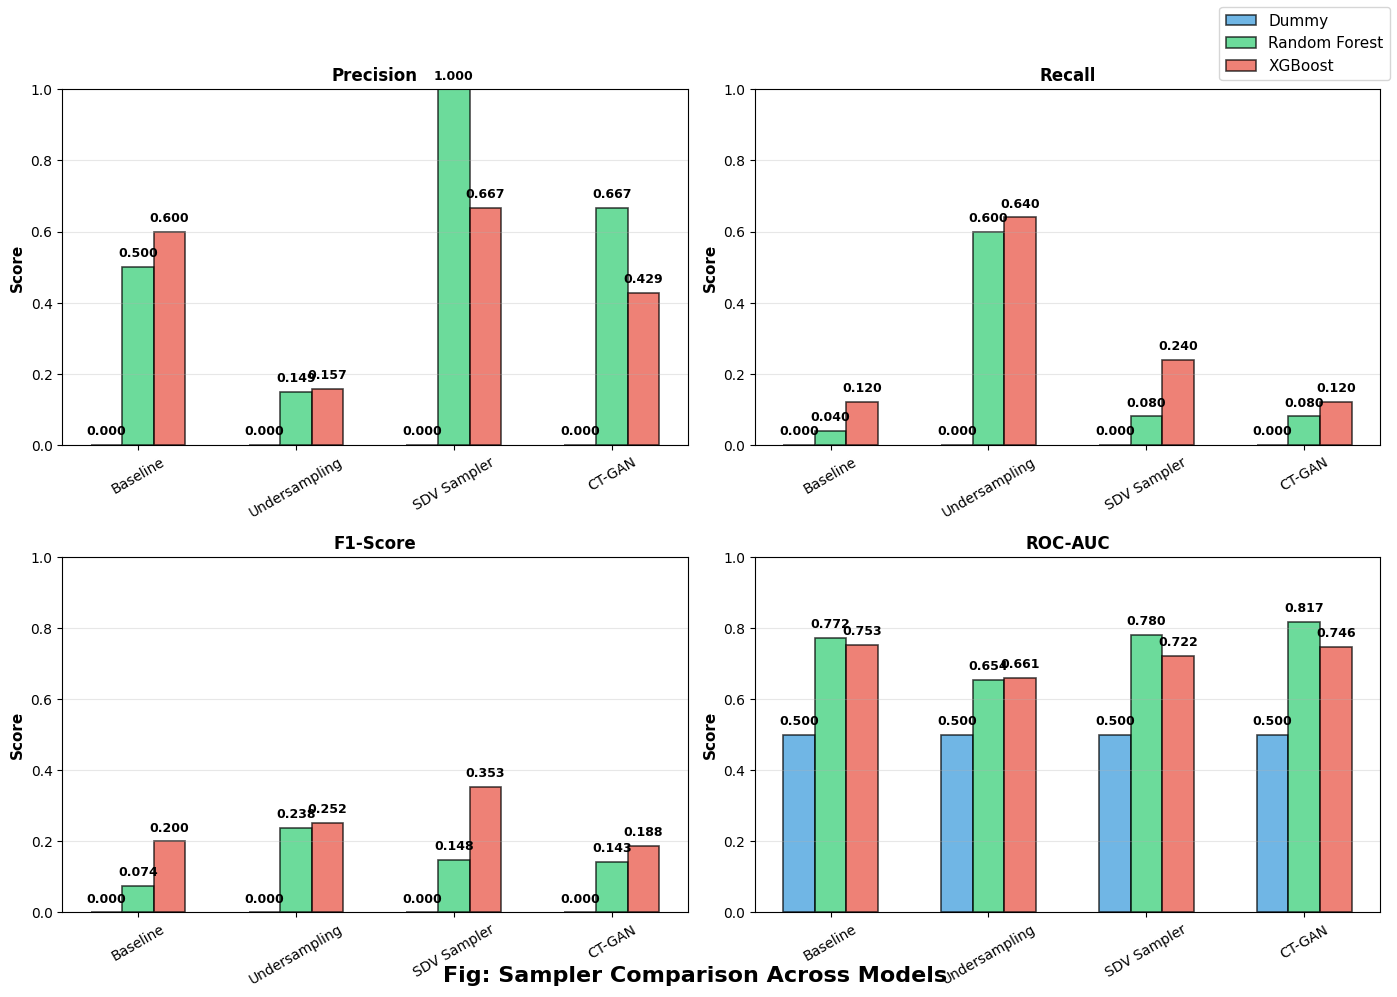

In [ ]:
# plots

metrics_list = ['precision', 'recall', 'f1', 'roc_auc']
metrics_titles = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']  # for up to 3 models

sampler_names = list(samplers_metrics.keys())
model_names = sorted({m for _, metrics_dict in samplers_metrics.values() for m in metrics_dict.keys()})

# 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#fig.suptitle('Sampler Comparison Across Models', fontsize=16, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics_list, metrics_titles)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    # Plot bars for each model
    for i, model_name in enumerate(model_names):
        values = []
        for sampler in sampler_names:
            # Extract metrics safely
            metrics_dict = samplers_metrics[sampler][1]  # second element assumed metrics dict
            model_metrics = metrics_dict.get(model_name, {})
            values.append(model_metrics.get(metric, 0))  # default 0 if missing

        # x positions with offsets for multiple models
        x = np.arange(len(sampler_names)) + i*0.2
        ax.bar(x, values, width=0.2, label=model_name, alpha=0.7,
               edgecolor='black', linewidth=1.2, color=colors[i % len(colors)])

    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.set_xticks(np.arange(len(sampler_names)) + 0.2*(len(model_names)-1)/2)
    ax.set_xticklabels(sampler_names, rotation=30)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, model_name in enumerate(model_names):
        for j, sampler in enumerate(sampler_names):
            metrics_dict = samplers_metrics[sampler][1]
            val = metrics_dict.get(model_name, {}).get(metric, 0)
            ax.text(j + 0.2*i, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# # Only one legend for all plots
# handles, labels = axes[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=len(model_names), fontsize=11)

# Legend at top right
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=11)

# Title at bottom center
fig.text(0.5, 0.02, 'Fig: Sampler Comparison Across Models',
         ha='center', fontsize=16, fontweight='bold')


plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
